# LSTM

## Import libraries

In [1]:
import os
import sys
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [2]:
FROM_DATE = "2020-01-01"
TO_DATE = "2020-02-28"

## Start

### Get data

In [3]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [4]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [5]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [6]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [7]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [8]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [9]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [10]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [11]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [12]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2020-01-01,962.985000,966.190000,958.945000,963.830000,135126340.0
1,2020-01-02,960.260000,966.670000,959.670000,966.670000,128410670.0
2,2020-01-03,968.720000,970.880000,965.140000,965.140000,144668880.0
3,2020-01-05,964.766667,967.053333,958.773333,958.906667,139596007.0
4,2020-01-06,962.790000,965.140000,955.590000,955.790000,137059570.0
5,2020-01-07,955.790000,959.460000,953.190000,958.880000,126566780.0
6,2020-01-08,954.130000,958.880000,945.280000,948.980000,175534190.0
7,2020-01-09,953.860000,960.730000,948.980000,960.150000,130690470.0
8,2020-01-10,961.170000,969.710000,960.150000,968.540000,160461650.0
9,2020-01-11,963.076667,969.350000,961.696667,967.640000,145577133.0


### Create plot

In [13]:
my_visualizer = Visualizer(logger=my_logger)

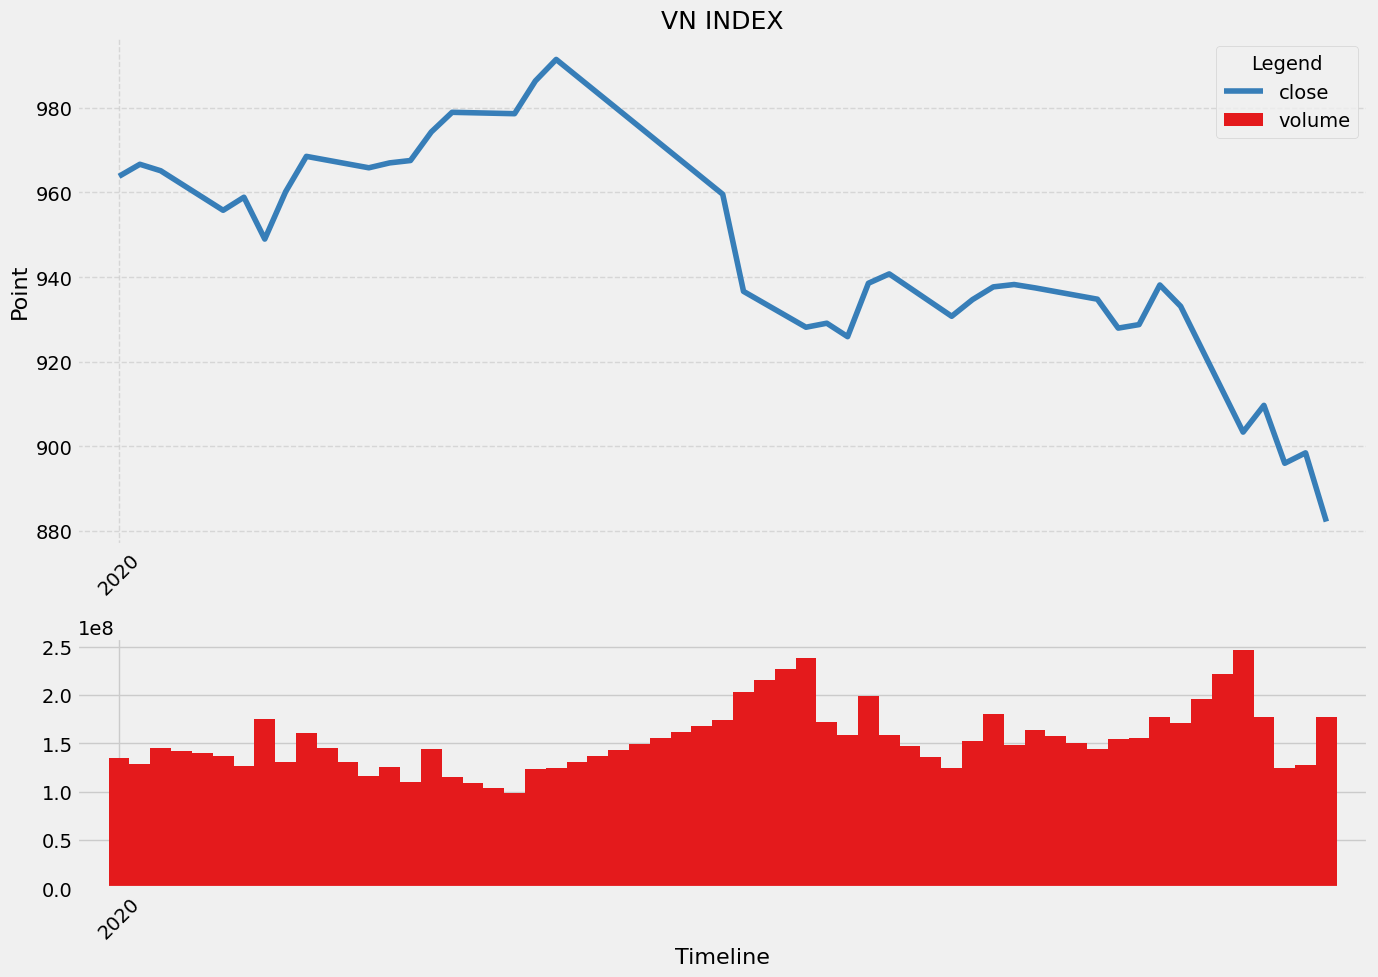

In [15]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create model